In [1]:
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, VotingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

# Metrics
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [2]:
df = pd.read_csv('AuthentiText_X_2026_AI_vs_Human_Detection_1K.csv')

print(df.head())
print(df.info())
print(df.describe())

    text_id                                       content_text author_type  \
0  TXT_0001  learning pattern detection algorithm pattern n...          AI   
1  TXT_0002  algorithm algorithm data research network mode...       Human   
2  TXT_0003  analysis language generation research pattern ...       Human   
3  TXT_0004  data language system learning content data net...          AI   
4  TXT_0005  model learning content language model generati...          AI   

  model_source  prompt_complexity_score  perplexity_score  burstiness_index  \
0        Human                    0.029             73.75             0.953   
1       Claude                    0.605             43.11             0.054   
2        GPT-4                    0.396             59.97             0.709   
3        GPT-4                    0.299             18.99             0.532   
4        Human                    0.867             82.45             0.478   

   syntactic_variability  semantic_coherence_score  lexi

In [3]:
print(df.isnull().sum())

# Fill or drop missing values
df = df.dropna()

text_id                        0
content_text                   0
author_type                    0
model_source                   0
prompt_complexity_score        0
perplexity_score               0
burstiness_index               0
syntactic_variability          0
semantic_coherence_score       0
lexical_diversity_ratio        0
readability_grade_level        0
generation_confidence_score    0
dtype: int64


In [4]:
label_encoders = {}

for col in df.select_dtypes(include=['object']).columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le

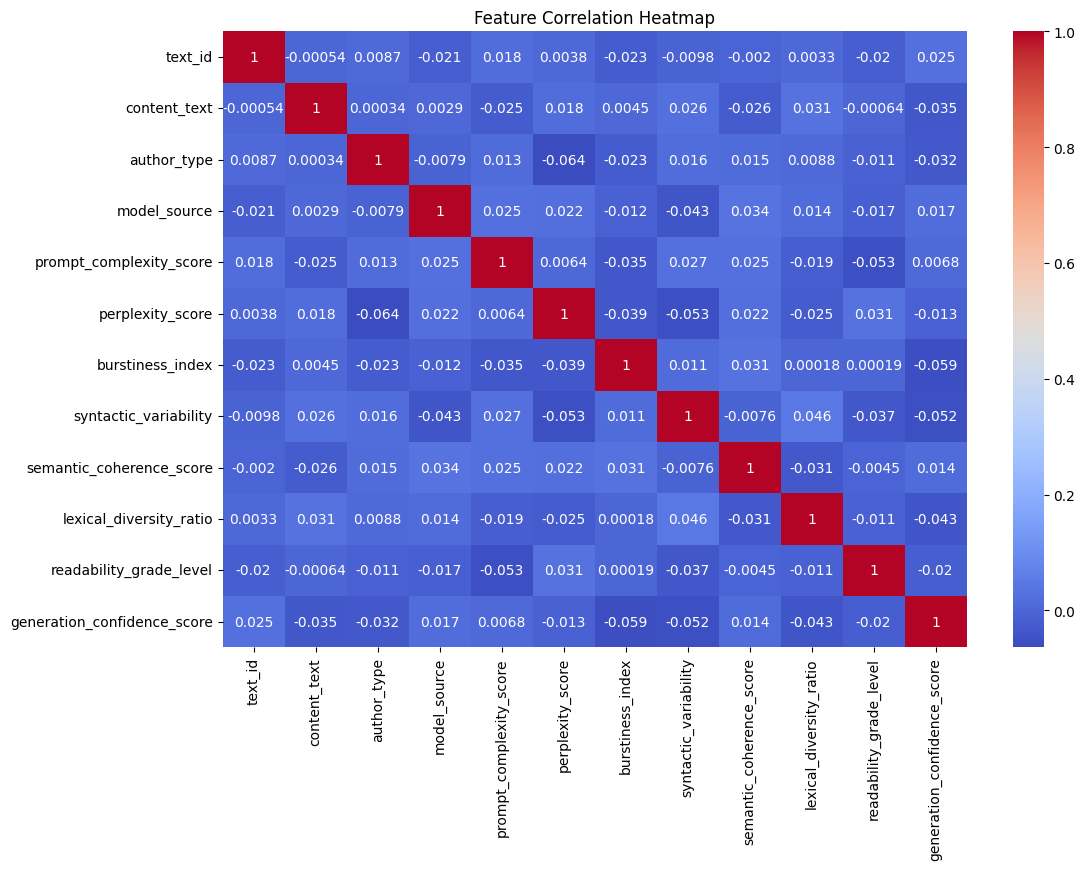

In [5]:
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Feature Correlation Heatmap")
plt.show()

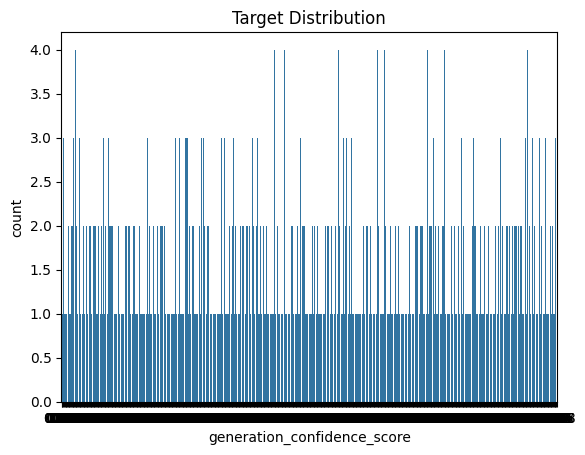

In [6]:
target_column = df.columns[-1]  # assuming last column is target

sns.countplot(x=df[target_column])
plt.title("Target Distribution")
plt.show()

In [7]:
X = df.drop(columns=['generation_confidence_score'])

In [8]:
y = (df['generation_confidence_score'] > 0.5).astype(int)

In [9]:
print(y.head())
print(y.unique())

0    0
1    0
2    0
3    1
4    0
Name: generation_confidence_score, dtype: int64
[0 1]


In [10]:
print(y.value_counts())

generation_confidence_score
0    502
1    498
Name: count, dtype: int64


In [11]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [13]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
models = {
    "Logistic Regression": LogisticRegression(),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "SVM": SVC(),
    "KNN": KNeighborsClassifier(),
    "Gradient Boosting": GradientBoostingClassifier()
}

results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    results[name] = acc

    print(f"\n{name}")
    print("Accuracy:", acc)
    print(classification_report(y_test, y_pred))


In [ ]:
voting_clf = VotingClassifier(
    estimators=[
        ('lr', LogisticRegression()),
        ('rf', RandomForestClassifier()),
        ('gb', GradientBoostingClassifier())
    ],
    voting='hard'
)

voting_clf.fit(X_train, y_train)
y_pred = voting_clf.predict(X_test)

ensemble_acc = accuracy_score(y_test, y_pred)

print("\nVoting Classifier Accuracy:", ensemble_acc)

In [ ]:
results["Voting Classifier"] = ensemble_acc

results_df = pd.DataFrame(list(results.items()), columns=["Model", "Accuracy"])
results_df = results_df.sort_values(by="Accuracy", ascending=False)

print(results_df)

In [ ]:
plt.figure(figsize=(10, 6))
sns.barplot(x="Accuracy", y="Model", data=results_df)
plt.title("Model Comparison")
plt.show()

In [ ]:
best_model_name = results_df.iloc[0]["Model"]
best_accuracy = results_df.iloc[0]["Accuracy"]

print(f"Best Model: {best_model_name}")
print(f"Accuracy: {best_accuracy}")

In [ ]:
best_model = models.get(best_model_name, voting_clf)

y_pred = best_model.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(max_features=5000)

X_text = vectorizer.fit_transform(df['text'])